In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [38]:
df = pd.read_csv('jabodetabek_house_price.csv')
df.head()

,url,price_in_rp,title,address,district,city,lat,long,facilities,property_type,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,https://www.rumah123.com/properti/bekasi/hos11...,2.990000e+09,Rumah cantik Sumarecon Bekasi\nLingkungan asri...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Tempat Jemuran, Jalur Telepon, Taman, Taman",rumah,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,https://www.rumah123.com/properti/bekasi/hos10...,1.270000e+09,"Rumah Kekinian, Magenta Summarecon Bekasi","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,Taman,rumah,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,https://www.rumah123.com/properti/bekasi/hos10...,1.950000e+09,Rumah Cantik 2 Lantai Cluster Bluebell Summare...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Masjid, Taman,...",rumah,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,https://www.rumah123.com/properti/bekasi/hos10...,3.300000e+09,Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jalur Telepon, Jogging Track, Track Lari, K...",rumah,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,https://www.rumah123.com/properti/bekasi/hos10...,4.500000e+09,"Rumah Hoek di Cluster Maple Summarecon Bekasi,...","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Taman, Jalur Te...",rumah,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   3553 non-null   object 
 1   price_in_rp           3553 non-null   float64
 2   title                 3553 non-null   object 
 3   address               3553 non-null   object 
 4   district              3553 non-null   object 
 5   city                  3553 non-null   object 
 6   lat                   3553 non-null   float64
 7   long                  3553 non-null   float64
 8   facilities            3553 non-null   object 
 9   property_type         3552 non-null   object 
 10  ads_id                3549 non-null   object 
 11  bedrooms              3519 non-null   float64
 12  bathrooms             3524 non-null   float64
 13  land_size_m2          3551 non-null   float64
 14  building_size_m2      3551 non-null   float64
 15  carports             

In [40]:
df.describe()

,price_in_rp,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,garages
count,3.553000e+03,3553.000000,3553.000000,3519.000000,3524.000000,3551.000000,3551.000000,3553.000000,3553.000000,3553.000000,3547.000000,2108.000000,2108.000000,3553.000000
mean,4.191685e+09,-6.324721,106.792881,3.326513,2.624858,204.806815,186.587440,1.197861,0.496482,0.370391,1.764590,3.880930,2018.137097,0.708978
std,1.375067e+10,0.129245,0.172159,2.672148,2.696497,402.127746,248.443471,1.114996,0.685723,0.536024,0.637349,7.603708,7.641448,1.311879
min,4.200000e+07,-6.894828,106.402315,1.000000,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1870.000000,0.000000
25%,8.000000e+08,-6.397933,106.687295,2.000000,2.000000,75.000000,65.500000,1.000000,0.000000,0.000000,1.000000,0.000000,2016.000000,0.000000
50%,1.500000e+09,-6.300733,106.799954,3.000000,2.000000,108.000000,112.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2021.000000,0.000000
75%,3.590000e+09,-6.231754,106.874766,4.000000,3.000000,192.000000,208.000000,2.000000,1.000000,1.000000,2.000000,6.000000,2022.000000,1.000000
max,5.800000e+11,-6.102478,109.771691,99.000000,99.000000,8000.000000,6000.000000,15.000000,7.000000,5.000000,5.000000,152.000000,2052.000000,50.000000


In [41]:
df['city'].value_counts()

city
Bogor              881
Tangerang          851
Bekasi             586
Depok              526
Jakarta Selatan    240
Jakarta Barat      206
Jakarta Utara      130
Jakarta Timur       95
Jakarta Pusat       38
Name: count, dtype: int64

In [42]:
df['city'].unique()

array([' Bekasi', ' Bogor', ' Depok', ' Jakarta Barat',
       ' Jakarta Selatan', ' Jakarta Utara', ' Jakarta Timur',
       ' Jakarta Pusat', ' Tangerang'], dtype=object)

##**Business Understanding**

**Latar Belakang**


**Tujuan Bisnis (Business Objectives)**

Tujuan utama dari proyek ini adalah:

1. Membangun model prediksi harga rumah di Kota Tangerang
2. Mengidentifikasi faktor-faktor utama yang paling berpengaruh terhadap harga rumah
3. Menyediakan estimasi harga yang objektif dan berbasis data


Membantu:

* Calon pembeli → menilai kewajaran harga


**Pertanyaan Analitis (Business Questions)**

1. Beberapa pertanyaan yang ingin dijawab:
2. Faktor apa yang paling memengaruhi harga rumah di Tangerang?
Seberapa besar pengaruh:
* Ukuran tanah vs ukuran bangunan?
* Lokasi (district)?
* Umur bangunan?

3. Apakah rumah dengan fasilitas tambahan memiliki peningkatan harga signifikan?
4. Seberapa akurat model dalam memprediksi harga rumah baru vs lama?


In [43]:
df_tangerang = df[df['city'] == ' Tangerang'].copy()

In [44]:
df_tangerang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 851 entries, 2702 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   851 non-null    object 
 1   price_in_rp           851 non-null    float64
 2   title                 851 non-null    object 
 3   address               851 non-null    object 
 4   district              851 non-null    object 
 5   city                  851 non-null    object 
 6   lat                   851 non-null    float64
 7   long                  851 non-null    float64
 8   facilities            851 non-null    object 
 9   property_type         850 non-null    object 
 10  ads_id                848 non-null    object 
 11  bedrooms              844 non-null    float64
 12  bathrooms             843 non-null    float64
 13  land_size_m2          850 non-null    float64
 14  building_size_m2      850 non-null    float64
 15  carports              85

##**Data Understanding**

bertujuan untuk memahami isi, struktur, kualitas, dan karakteristik data sebelum dilakukan pembersihan, analisis mendalam, dan pemodelan.

Pada tahap ini yang dilakukan:

1. Mengenal data
2. Menilai kelayakan data
3. Mengidentifikasi potensi masalah
3. Membentuk hipotesis awal

Tahap ini sangat krusial karena:

"Model yang baik tidak mungkin dibangun dari data yang tidak dipahami."

In [45]:
df_tangerang['ads_id']

2702    hos11357245
2703    hos11287789
2704     hos7565011
2705    hos11145237
2706    hos11086497
           ...     
3548    hos11361759
3549    hos11359615
3550    hos11359594
3551    hos11359313
3552    hos11358964
Name: ads_id, Length: 851, dtype: object

In [46]:
# Menghapus kolom yang tidak diperlukan

df_tangerang.drop(columns=['url', 'title', 'ads_id', 'address', 'lat', 'long', 'certificate'], inplace=True)

In [47]:
df_tangerang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 851 entries, 2702 to 3552
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price_in_rp           851 non-null    float64
 1   district              851 non-null    object 
 2   city                  851 non-null    object 
 3   facilities            851 non-null    object 
 4   property_type         850 non-null    object 
 5   bedrooms              844 non-null    float64
 6   bathrooms             843 non-null    float64
 7   land_size_m2          850 non-null    float64
 8   building_size_m2      850 non-null    float64
 9   carports              851 non-null    float64
 10  electricity           851 non-null    object 
 11  maid_bedrooms         851 non-null    float64
 12  maid_bathrooms        851 non-null    float64
 13  floors                849 non-null    float64
 14  building_age          481 non-null    float64
 15  year_built            48

In [48]:
df_tangerang.head()

,price_in_rp,district,city,facilities,property_type,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
2702,3.830000e+09,Alam Sutera,Tangerang,"Keamanan, Jalur Telepon, Akses Parkir, Wastaf...",rumah,3.0,3.0,105.0,135.0,1.0,3500 mah,0.0,1.0,2.0,0.0,2022.0,baru,selatan,2.0,semi furnished
2703,5.860000e+09,Alam Sutera,Tangerang,"Keamanan, Taman, Jogging Track, Pemanas Air...",rumah,4.0,3.0,160.0,209.0,1.0,3500 mah,0.0,1.0,2.0,0.0,2022.0,baru,utara,2.0,semi furnished
2704,3.190000e+09,Alam Sutera,Tangerang,"Keamanan, CCTV, Jogging Track, Taman, Kolam...",rumah,5.0,4.0,124.0,138.0,2.0,2200 mah,1.0,1.0,2.0,1.0,2021.0,baru,timur,3.0,semi furnished
2705,1.240000e+10,Alam Sutera,Tangerang,"Ac, Keamanan, Jogging Track, CCTV, Jalur Te...",rumah,6.0,5.0,320.0,390.0,2.0,5500 mah,0.0,1.0,3.0,0.0,2022.0,baru,selatan,3.0,semi furnished
2706,3.750000e+09,Alam Sutera,Tangerang,"Jalur Telepon, Kitchen Set, Keamanan 24 jam, A...",rumah,5.0,3.0,200.0,150.0,0.0,3500 mah,1.0,1.0,1.0,NaN,NaN,bagus,timur,0.0,furnished


In [49]:
df_tangerang['district'].unique()

array(['Alam Sutera', 'Gading Serpong', 'BSD City', 'BSD The Icon',
       'BSD Kencana Loka', 'BSD Delatinos', 'Cikupa Citra Raya', 'BSD',
       'Pinang', 'Ciledug', 'Rawakalong', 'Sindang Jaya', 'Cisauk',
       'Curug', 'Pagedangan', 'Kelapa Dua', 'Karawaci', 'Cikokol',
       'Cibodas', 'Panongan', 'Cikupa', 'BSD De Park', 'Serua',
       'Lippo Karawaci', 'Cipondoh', 'Tangerang Kota', 'Pondok Cabe',
       'Graha Raya', 'Gading Serpong IL Lago', 'BSD Green Wich',
       'BSD Giri Loka', 'BSD Eminent', 'Larangan', 'BSD Foresta',
       'Modernland', 'BSD Nusaloka', 'Poris', 'Cipadu', 'Batu Ceper',
       'Pengasinan', 'Karang Tengah', 'BSD Sevilla', 'Rempoa',
       'Tanah Tinggi', 'Sutera Sitara Alam Sutera', 'BSD Taman Giri Loka',
       'Pasar Kemis', 'BSD Graha Raya', 'Pesanggrahan', 'Bitung',
       'Gading Serpong Pondok Hijau Golf', 'Ciater', 'Parigi',
       'Tigaraksa', 'Gading Serpong Andalucia',
       'Gading Serpong The Spring', 'Banjar Wijaya', 'Tajur', 'Cireundeu',


In [50]:
df_tangerang['district'].value_counts()

district
Alam Sutera              115
Gading Serpong            97
BSD                       83
BSD City                  76
Cikupa Citra Raya         32
                        ... 
BSD Anggrek Loka           1
Benda                      1
Jombang                    1
BSD Provance Parkland      1
Sudimara                   1
Name: count, Length: 93, dtype: int64

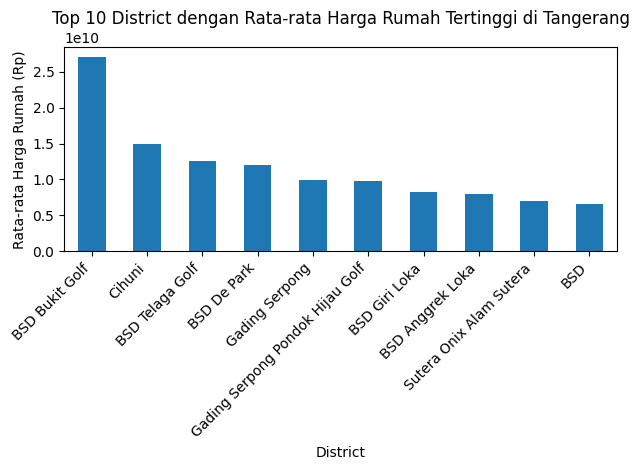

In [51]:
# Hitung rata-rata harga rumah per district
avg_price_district = (
    df_tangerang
    .groupby('district')['price_in_rp']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Visualisasi
plt.figure()
avg_price_district.plot(kind='bar')
plt.title('Top 10 District dengan Rata-rata Harga Rumah Tertinggi di Tangerang')
plt.xlabel('District')
plt.ylabel('Rata-rata Harga Rumah (Rp)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**Data Prepocessing**
Data Preprocessing adalah tahap lanjutan setelah Data Understanding yang bertujuan untuk menyiapkan data mentah agar layak digunakan oleh model machine learning.

Tujuan utama preprocessing dalam proyek ini adalah:

1. Menangani missing values
2. Menghilangkan atau memperbaiki data tidak valid
3. Menyeragamkan format dan skala data
4. Mengubah data kategorikal menjadi numerik
5. Menyiapkan fitur yang relevan untuk prediksi harga rumah

In [52]:
df_tangerang.isnull().sum()

price_in_rp               0
district                  0
city                      0
facilities                0
property_type             1
bedrooms                  7
bathrooms                 8
land_size_m2              1
building_size_m2          1
carports                  0
electricity               0
maid_bedrooms             0
maid_bathrooms            0
floors                    2
building_age            370
year_built              370
property_condition       58
building_orientation    382
garages                   0
furnishing               71
dtype: int64

In [53]:
df_tangerang.drop(columns=['building_age', 'year_built', 'building_orientation', 'property_type'], inplace=True)

<Axes: >

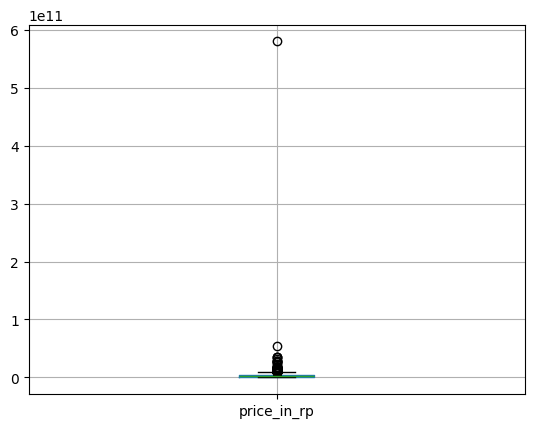

In [54]:
df_tangerang.boxplot(column=['price_in_rp'])

<Axes: >

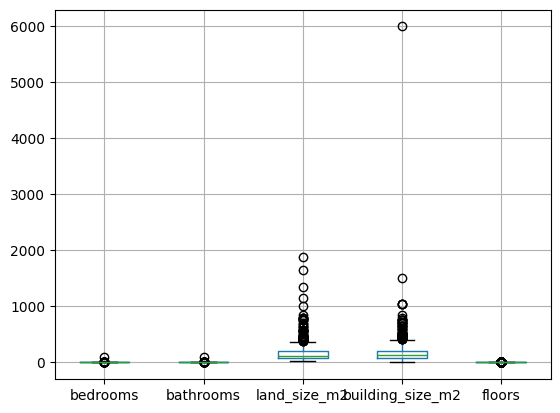

In [55]:
df_tangerang.boxplot(column=['bedrooms', 'bathrooms', 'land_size_m2', 'building_size_m2', 'floors'],)

In [56]:
df_tangerang['price_in_rp'].fillna(df_tangerang['price_in_rp'].median(), inplace=True)
df_tangerang['bedrooms'].fillna(df_tangerang['bedrooms'].median(), inplace=True)
df_tangerang['bathrooms'].fillna(df_tangerang['bathrooms'].median(), inplace=True)
df_tangerang['land_size_m2'].fillna(df_tangerang['land_size_m2'].median(), inplace=True)
df_tangerang['building_size_m2'].fillna(df_tangerang['building_size_m2'].median(), inplace=True)
df_tangerang['floors'].fillna(df_tangerang['floors'].median(), inplace=True)

df_tangerang['property_condition'].fillna(df_tangerang['property_condition'].mode()[0], inplace=True)
df_tangerang['furnishing'].fillna(df_tangerang['furnishing'].mode()[0], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8696\3168698712.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tangerang['price_in_rp'].fillna(df_tangerang['price_in_rp'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_8696\3168698712.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

In [57]:
df_tangerang.isnull().sum()

price_in_rp           0
district              0
city                  0
facilities            0
bedrooms              0
bathrooms             0
land_size_m2          0
building_size_m2      0
carports              0
electricity           0
maid_bedrooms         0
maid_bathrooms        0
floors                0
property_condition    0
garages               0
furnishing            0
dtype: int64

In [58]:
df_tangerang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 851 entries, 2702 to 3552
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price_in_rp         851 non-null    float64
 1   district            851 non-null    object 
 2   city                851 non-null    object 
 3   facilities          851 non-null    object 
 4   bedrooms            851 non-null    float64
 5   bathrooms           851 non-null    float64
 6   land_size_m2        851 non-null    float64
 7   building_size_m2    851 non-null    float64
 8   carports            851 non-null    float64
 9   electricity         851 non-null    object 
 10  maid_bedrooms       851 non-null    float64
 11  maid_bathrooms      851 non-null    float64
 12  floors              851 non-null    float64
 13  property_condition  851 non-null    object 
 14  garages             851 non-null    float64
 15  furnishing          851 non-null    object 
dtypes: float6

In [59]:
print(df_tangerang['furnishing'].unique())
print(df_tangerang['property_condition'].unique())

['semi furnished' 'furnished' 'unfurnished' 'baru']
['baru' 'bagus' 'bagus sekali' 'sudah renovasi' 'butuh renovasi'
 'unfurnished']


In [60]:
df_tangerang.loc[
    df_tangerang['furnishing'] == 'baru',
    'furnishing'] = 'unfurnished'


condition_map = {
    'butuh renovasi': 0,
    'bagus': 1,
    'bagus sekali': 2,
    'sudah renovasi': 3,
    'baru': 4
}
furnishing_map = {
    'unfurnished': 0,
    'semi furnished': 1,
    'furnished': 2
}

df_tangerang['furnishing'] = df_tangerang['furnishing'].map(furnishing_map)
df_tangerang['property_condition'] = (df_tangerang['property_condition'].map(condition_map))


In [61]:
df_tangerang['electricity']

2702    3500 mah
2703    3500 mah
2704    2200 mah
2705    5500 mah
2706    3500 mah
          ...   
3548    1300 mah
3549    1300 mah
3550    1300 mah
3551    2200 mah
3552    1300 mah
Name: electricity, Length: 851, dtype: object

In [62]:
df_tangerang['electricity'] = (
    df_tangerang['electricity']
    .str.extract(r'(\d+)')
    .astype(float)
)

In [63]:
df_tangerang['facilities']

2702     Keamanan, Jalur Telepon, Akses Parkir, Wastaf...
2703     Keamanan,  Taman, Jogging Track,  Pemanas Air...
2704     Keamanan, CCTV,  Jogging Track,  Taman, Kolam...
2705     Ac,  Keamanan,  Jogging Track, CCTV, Jalur Te...
2706    Jalur Telepon, Kitchen Set, Keamanan 24 jam, A...
                              ...                        
3548    Masjid,  Taman, Tempat Jemuran, Keamanan 24 ja...
3549    Masjid,  Keamanan,  Jogging Track,  Taman, Tem...
3550     Keamanan,  Taman, Jogging Track, Tempat Jemur...
3551    Tempat Jemuran, Keamanan, Keamanan 24 jam, Was...
3552    Kulkas, Masjid,  Taman, Lapangan Bola, Tempat ...
Name: facilities, Length: 851, dtype: object

In [64]:
df_tangerang['facilities'] = (
    df_tangerang['facilities']
    .str.split(',')
    .apply(len)
)


In [65]:
df_tangerang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 851 entries, 2702 to 3552
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price_in_rp         851 non-null    float64
 1   district            851 non-null    object 
 2   city                851 non-null    object 
 3   facilities          851 non-null    int64  
 4   bedrooms            851 non-null    float64
 5   bathrooms           851 non-null    float64
 6   land_size_m2        851 non-null    float64
 7   building_size_m2    851 non-null    float64
 8   carports            851 non-null    float64
 9   electricity         781 non-null    float64
 10  maid_bedrooms       851 non-null    float64
 11  maid_bathrooms      851 non-null    float64
 12  floors              851 non-null    float64
 13  property_condition  849 non-null    float64
 14  garages             851 non-null    float64
 15  furnishing          851 non-null    int64  
dtypes: float6

In [66]:
district_mean_price = (
    df_tangerang
    .groupby('district')['price_in_rp']
    .mean()
)
df_tangerang['district_encoded'] = df_tangerang['district'].map(district_mean_price)

In [67]:
X = df_tangerang.drop(columns=['price_in_rp', 'district', 'city'])
y = df_tangerang['price_in_rp']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelling

Modelling adalah fase di mana data yang telah dipersiapkan digunakan untuk membangun dan melatih model prediktif.

Tujuan Tahap Modelling

1. Memilih algoritma yang sesuai dengan permasalahan
2. Melatih model menggunakan data latih
3. Menentukan parameter model
4. Menghasilkan model yang mampu melakukan prediksi dengan baik

In [69]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluasi

untuk menilai kinerja model yang telah dibangun pada tahap Modeling

Tujuan Evaluasi pada Proyek Ini

Pada proyek Prediksi Harga Rumah di Kota Tangerang, evaluasi dilakukan untuk:

1. Mengukur akurasi prediksi harga rumah
2. Menilai seberapa besar kesalahan prediksi model
3. Membandingkan performa model (jika ada lebih dari satu)

In [70]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'mae = {mae}')
print(f'rmse = {rmse}')
print(f'r2 = {r2}')

mae = 506322548.9650051
rmse = 997676623.366342
r2 = 0.9428317892799065


In [71]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(5)

land_size_m2        0.542945
building_size_m2    0.209649
bedrooms            0.048416
facilities          0.041961
carports            0.038737
dtype: float64

In [72]:
joblib.dump(model, 'model.pkl')
joblib.dump(district_mean_price, 'district_mean_price.pkl')

['district_mean_price.pkl']

In [73]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 851 entries, 2702 to 3552
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   facilities          851 non-null    int64  
 1   bedrooms            851 non-null    float64
 2   bathrooms           851 non-null    float64
 3   land_size_m2        851 non-null    float64
 4   building_size_m2    851 non-null    float64
 5   carports            851 non-null    float64
 6   electricity         781 non-null    float64
 7   maid_bedrooms       851 non-null    float64
 8   maid_bathrooms      851 non-null    float64
 9   floors              851 non-null    float64
 10  property_condition  849 non-null    float64
 11  garages             851 non-null    float64
 12  furnishing          851 non-null    int64  
 13  district_encoded    851 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 99.7 KB
